### 심박수 모니터링 시스템

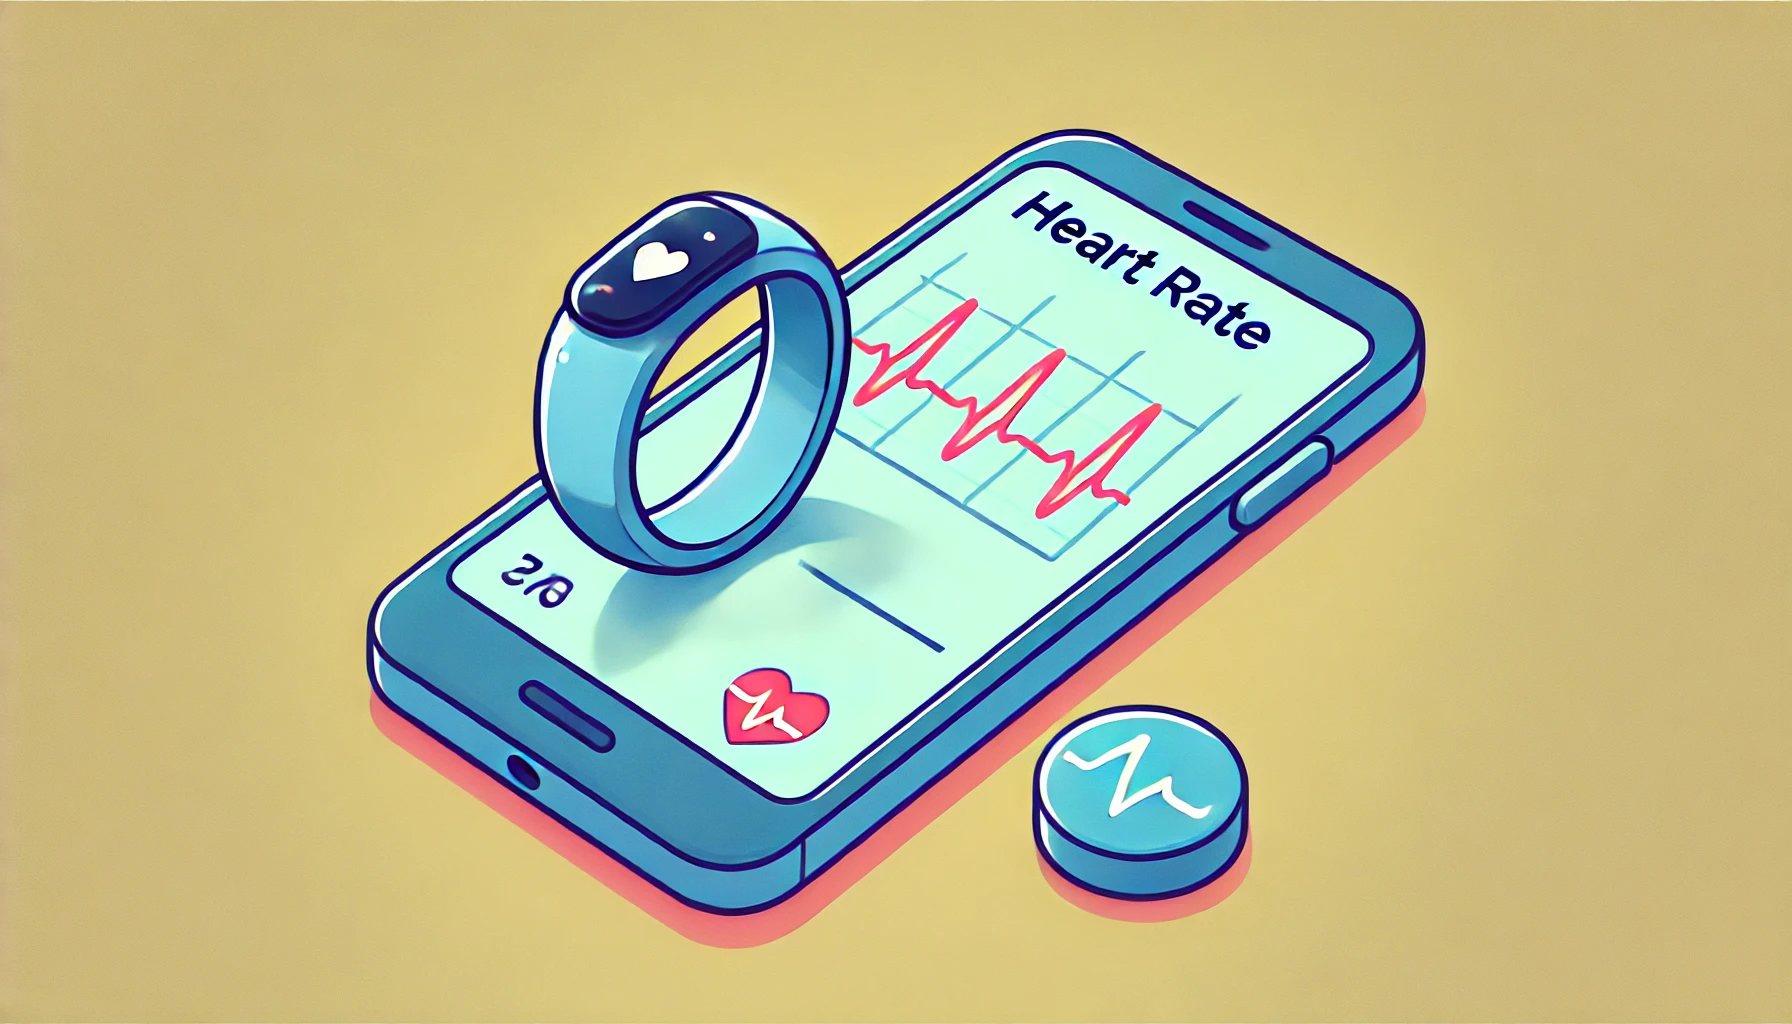

In [1]:
from IPython.display import Image
Image(filename="./images/Project 2.png")

### 문제

주안이는 디지털 헬스케어 회사에서 스마트링을 개발하고 있습니다. 이 작은 반지는 환자의 심박수를 측정할 수 있어 핸드폰으로 연동해 실시간으로 심박수를 확인할 수 있습니다. 문제는 반지의 센서가 너무 민감해서 가끔씩 크거나 작은 이상치를 기록할 때가 있다는 것입니다. 이 문제의 대표적인 해결 방법은 데이터의 중앙값을 알려주는 것입니다. 데이터의 개수가 홀수 개일 경우 데이터를 정렬했을 때 가운데에 있는 값이 중앙값이고, 데이터의 개수가 짝수일 경우 중앙에 위치한 두 값의 평균이 중앙값이 됩니다.

데이터가 계속해서 추가되는 상황에서 매번 중앙값을 효율적으로 구하려면, 최소 힙에 큰 절반의 수들을 저장하고, 최대 힙에 작은 절반의 수들을 저장하도록 유지하며 두 힙의 루트 노드를 이용하면 됩니다. 최소 힙의 루트 노드는 큰 절반의 수들 중 최솟값이니 중앙에 위치한 값이 되고, 최대 힙의 루트 노드 역시 작은 절반의 수들 중 최댓값이니 중앙에 위치한 값이 되기 때문입니다. “조건”에 심박수 모니터링 시스템의 자세한 구현 방법이 주어질 때, 주안이를 도와 심박수 모니터링 프로그램을 완성해 주세요.

### 조건

- add_value() 함수는 최소 힙과 최대 힙에 숫자를 추가하고 정렬을 유지하는 함수입니다.
    - 두 힙의 크기가 같을 경우, 최소 힙이 숫자가 1개 더 많도록 저장합니다.
    - 두 힙의 크기가 다를 경우, 최소 힙의 숫자가 1개 더 많으므로 최대 힙에 숫자를 저장해 두 힙의 크기를 같게 만듭니다.
    - 추가된 1개의 숫자로 인해 큰 절반의 최솟값이 작은 절반의 최댓값보다 작을 수 있습니다. 이 경우 두 수를 교환하면 재정렬됩니다.
- find_median() 함수는 현재까지 추가된 데이터 중에서 중앙값을 계산하고 반환하는 함수입니다.
    - 두 힙의 크기가 같을 경우, 데이터의 수가 짝수인 것이므로 두 힙의 루트 노드의 평균값이 중앙값입니다.
    - 두 힙의 크기가 다를 경우, 최소 힙의 숫자가 1개 더 많으므로 최소 힙의 루트 노드가 중앙값입니다.
- 힙의 크기는 len() 함수로 확인할 수 있으며, 각 힙의 루트 노드는 0번 인덱스로 접근할 수 있습니다.

In [2]:
# 완성 코드
import heapq

min_heap = []  # 큰 절반을 저장하는 최소 힙
max_heap = []  # 작은 절반을 저장하는 최대 힙 (부호를 반대로 저장)


def add_value(value):
    # 두 힙의 크기가 같으면 최소 힙이 숫자가 1개 더 많도록 저장
    if len(min_heap) == len(max_heap):
        heapq.heappush(min_heap, value)
    # 최소 힙의 크기가 더 크면 최소 힙과 최대 힙이 숫자를 절반씩 갖도록 저장
    else:
        heapq.heappush(max_heap, -value)

    # 최대 힙의 크기가 0이면 두 힙의 루트 노드를 교환할 수 없음
    if len(max_heap) == 0:
        return

    # 큰 절반의 최솟값이 작은 절반의 최댓값보다 작으면 두 값을 교환해서 재정렬
    if min_heap[0] < -max_heap[0]:
        max_heap_root = -heapq.heappop(max_heap)
        min_heap_root = heapq.heappop(min_heap)
        heapq.heappush(max_heap, -min_heap_root)
        heapq.heappush(min_heap, max_heap_root)


def find_median():
    # 두 힙의 크기가 같을 경우 숫자가 짝수 개이므로 두 중앙값의 평균값을 반환
    if len(min_heap) == len(max_heap):
        return (min_heap[0] + (-max_heap[0])) / 2
    # 두 힙의 크기가 다를 경우 최소 힙이 1 더 크므로 최소 힙의 루트 노드가 중앙값
    else:
        return min_heap[0]


heart_rates = [70, 82, 80, 999999, 74, 78, 0, 80, -2147483648, 80, 82, 81]
cnt = 0

for heart_rate in heart_rates:
    add_value(float(heart_rate))  # 각 데이터는 실수형으로 관리
    cnt += 1

    print(f"기록된 심박수 데이터: {heart_rates[:cnt]}")
    print(f"현재까지 기록된 일일 심박수는 {find_median()}bpm입니다.")
    print()

기록된 심박수 데이터: [70]
현재까지 기록된 일일 심박수는 70.0bpm입니다.

기록된 심박수 데이터: [70, 82]
현재까지 기록된 일일 심박수는 76.0bpm입니다.

기록된 심박수 데이터: [70, 82, 80]
현재까지 기록된 일일 심박수는 80.0bpm입니다.

기록된 심박수 데이터: [70, 82, 80, 999999]
현재까지 기록된 일일 심박수는 81.0bpm입니다.

기록된 심박수 데이터: [70, 82, 80, 999999, 74]
현재까지 기록된 일일 심박수는 80.0bpm입니다.

기록된 심박수 데이터: [70, 82, 80, 999999, 74, 78]
현재까지 기록된 일일 심박수는 79.0bpm입니다.

기록된 심박수 데이터: [70, 82, 80, 999999, 74, 78, 0]
현재까지 기록된 일일 심박수는 78.0bpm입니다.

기록된 심박수 데이터: [70, 82, 80, 999999, 74, 78, 0, 80]
현재까지 기록된 일일 심박수는 79.0bpm입니다.

기록된 심박수 데이터: [70, 82, 80, 999999, 74, 78, 0, 80, -2147483648]
현재까지 기록된 일일 심박수는 78.0bpm입니다.

기록된 심박수 데이터: [70, 82, 80, 999999, 74, 78, 0, 80, -2147483648, 80]
현재까지 기록된 일일 심박수는 79.0bpm입니다.

기록된 심박수 데이터: [70, 82, 80, 999999, 74, 78, 0, 80, -2147483648, 80, 82]
현재까지 기록된 일일 심박수는 80.0bpm입니다.

기록된 심박수 데이터: [70, 82, 80, 999999, 74, 78, 0, 80, -2147483648, 80, 82, 81]
현재까지 기록된 일일 심박수는 80.0bpm입니다.

